<a href="https://colab.research.google.com/github/tyleresong/mis433/blob/main/regression_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression Models

In [60]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

import seaborn as sns

In [61]:
diamonds = sns.load_dataset('diamonds')
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [62]:
diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [63]:
diamonds.describe(include='all')

,carat,cut,color,clarity,depth,table,price,x,y,z
count,53940.000000,53940,53940,53940,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,21551,11292,13065,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.797940,NaN,NaN,NaN,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,NaN,NaN,NaN,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,NaN,NaN,NaN,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,NaN,NaN,NaN,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,NaN,NaN,NaN,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,NaN,NaN,NaN,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000


In our exploratory data analysis (EDA), we’ve seen some surprising relationships between the quality of diamonds and their price: low quality diamonds (poor cuts, bad colours, and inferior clarity) have higher prices.

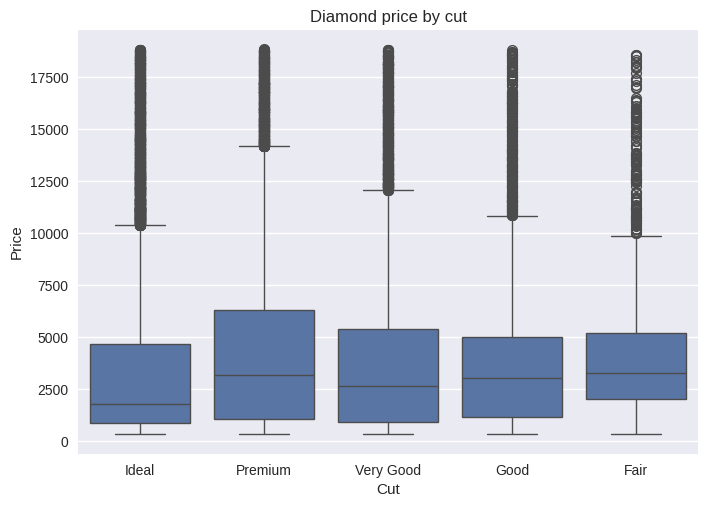

In [64]:
# Fair cuts have higher price?
fig, ax = plt.subplots()
sns.boxplot(data=diamonds, x='cut', y='price', ax=ax)
ax.set_xlabel("Cut")
ax.set_ylabel("Price")
ax.set_title("Diamond price by cut")
plt.show()

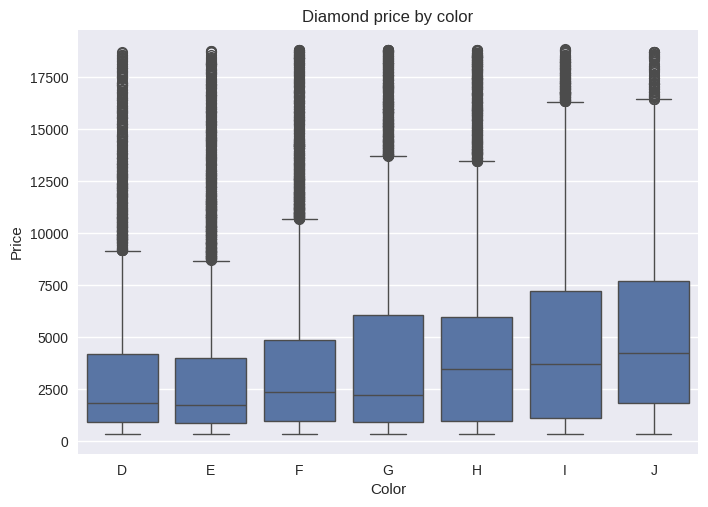

In [65]:
# The worst diamond color is J (slightly yellow)
fig, ax = plt.subplots()
sns.boxplot(data=diamonds, x='color', y='price', ax=ax)
ax.set_xlabel("Color")
ax.set_ylabel("Price")
ax.set_title("Diamond price by color")
plt.show()

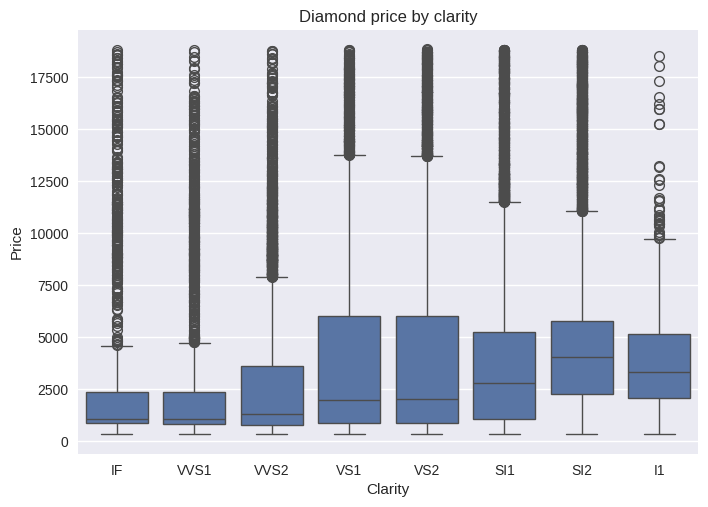

In [66]:
# The worst clarity is I1 (inclusions visible to the naked eye).
fig, ax = plt.subplots()
sns.boxplot(data=diamonds, x='clarity', y='price', ax=ax)
ax.set_xlabel("Clarity")
ax.set_ylabel("Price")
ax.set_title("Diamond price by clarity")
plt.show()

Do these charts mean lower quality diamonds have higher prices? If that's the case, why do people pay higher prices for lower quality?

Do not forget there is an important confounding variable: the weight (carat) of the diamond. The weight of the diamond is the single most important factor for determining the price of the diamond, and lower quality diamonds tend to be larger.

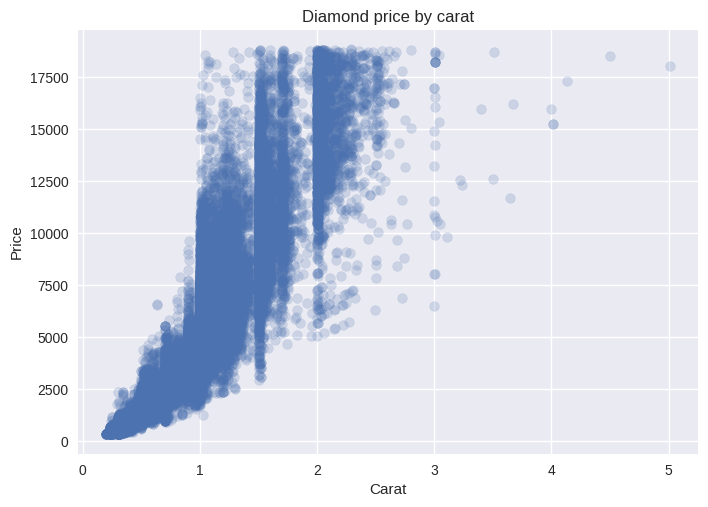

In [67]:
fig, ax = plt.subplots()
ax.scatter(diamonds['carat'], diamonds['price'], alpha=0.2)
ax.set_xlabel("Carat")
ax.set_ylabel("Price")
ax.set_title("Diamond price by carat")
plt.show()

## Build a Simple Regression Model for Diamond Price

We build a simple regression model to predict diamond price by carat.

In [68]:
# Use sklearn for linear regression
from sklearn.linear_model import LinearRegression

In [69]:
diamonds_y = diamonds['price']
diamonds_y

,price
0,326
1,326
2,327
3,334
4,335
...,...
53935,2757
53936,2757
53937,2757
53938,2757


In [70]:
# X as a dataframe (numpy array)
diamonds_X = diamonds[['carat']]
diamonds_X

,carat
0,0.23
1,0.21
2,0.23
3,0.29
4,0.31
...,...
53935,0.72
53936,0.72
53937,0.70
53938,0.86


In [71]:
lm1 = LinearRegression()
lm1.fit(diamonds_X, diamonds_y)

LinearRegression()

In [72]:
print(lm1.intercept_, lm1.coef_)

-2256.360580045403 [7756.42561797]


In [73]:
# R^2 of the model
lm1.score(diamonds_X, diamonds_y)

0.8493305264354858

In [74]:
# Calculate the predicted price
diamonds_y_pred = lm1.predict(diamonds_X)

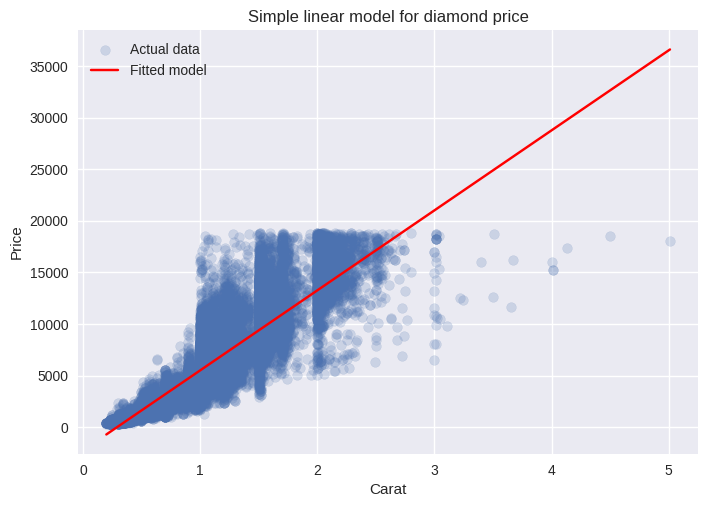

In [75]:
carat_grid = np.linspace(diamonds['carat'].min(), diamonds['carat'].max(), 200).reshape(-1, 1)
price_grid_pred = lm1.predict(pd.DataFrame(carat_grid, columns=['carat']))

fig, ax = plt.subplots()
ax.scatter(diamonds['carat'], diamonds['price'], alpha=0.2, label="Actual data")
ax.plot(carat_grid, price_grid_pred, color="red", label="Fitted model")
ax.set_xlabel("Carat")
ax.set_ylabel("Price")
ax.set_title("Simple linear model for diamond price")
ax.legend()
plt.show()

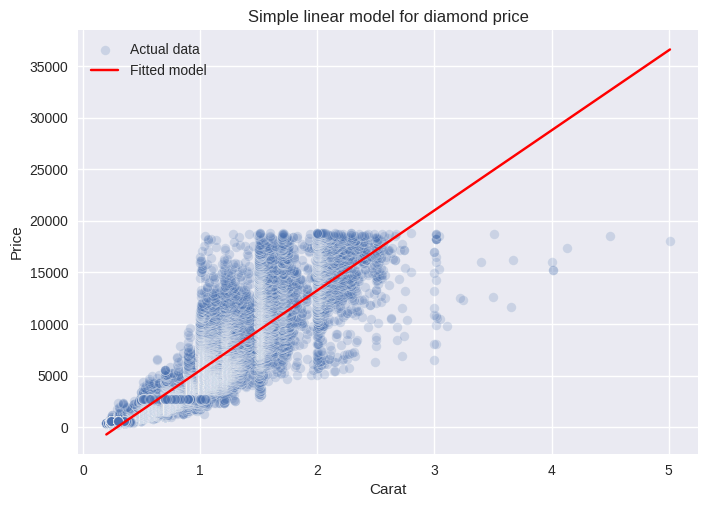

In [76]:
fig, ax = plt.subplots()
sns.scatterplot(data=diamonds, x='carat', y='price', alpha=0.2, label="Actual data", ax=ax)
ax.plot(carat_grid, price_grid_pred, color="red", label="Fitted model")
ax.set_xlabel("Carat")
ax.set_ylabel("Price")
ax.set_title("Simple linear model for diamond price")
ax.legend()
plt.show()

In [77]:
# RMSE: This indicates how off the predicted values are from the actual values.
from sklearn.metrics import root_mean_squared_error
lm1_rmse = root_mean_squared_error(diamonds_y, diamonds_y_pred)
lm1_rmse

1548.5331930613174

## Improving the model

Next, let's make a few tweaks to our model:
- Remove the outliers (big diamonds)
- Include other variables
- Examine non-linearity

### Remove outliers

In [78]:
# How many diamonds are larger than 2.5 carats (99.7% of the data)
bigrock = diamonds.carat>2.5
bigrock.value_counts(normalize=True)

,proportion
carat,
False,0.997664
True,0.002336


In [79]:
# Focus on diamonds smaller than 2.5 carats.
df = diamonds[diamonds.carat<=2.5]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53814 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53814 non-null  float64 
 1   cut      53814 non-null  category
 2   color    53814 non-null  category
 3   clarity  53814 non-null  category
 4   depth    53814 non-null  float64 
 5   table    53814 non-null  float64 
 6   price    53814 non-null  int64   
 7   x        53814 non-null  float64 
 8   y        53814 non-null  float64 
 9   z        53814 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.4 MB


In [80]:
df = df.reset_index().drop(columns=['index'])
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53809,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53810,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53811,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53812,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [81]:
df_X = df[['carat']]
df_y = df['price']

In [82]:
# Build a new linear model using data without the outliers
lm2 = LinearRegression()
lm2.fit(df_X, df_y)

LinearRegression()

In [83]:
print(lm2.intercept_, lm2.coef_)

-2330.655504678868 [7862.1680473]


In [84]:
# R^2 of the model
lm2.score(df_X, df_y)

0.8519722572415094

In [85]:
# Calculate the predicted price using the new model
y_pred = lm2.predict(df_X)

In [86]:
# Estimate the RMSE
root_mean_squared_error(df_y, y_pred)

1520.698006853508

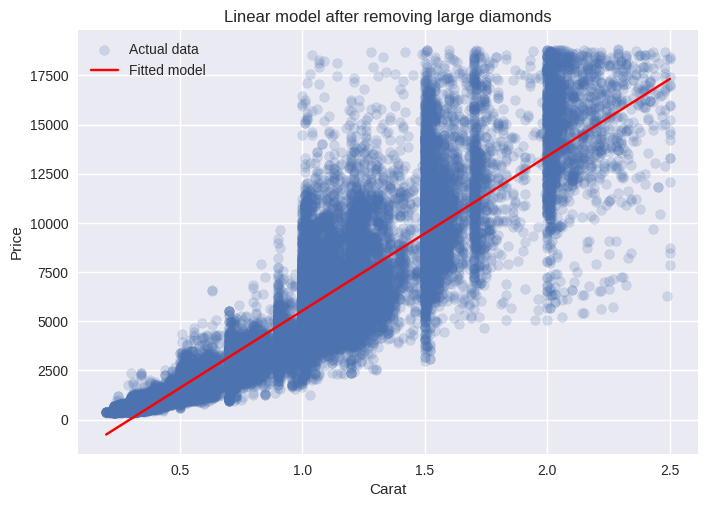

In [87]:
carat_grid = np.linspace(df['carat'].min(), df['carat'].max(), 200).reshape(-1, 1)
price_grid_pred = lm2.predict(pd.DataFrame(carat_grid, columns=['carat']))

fig, ax = plt.subplots()
ax.scatter(df['carat'], df['price'], alpha=0.2, label="Actual data")
ax.plot(carat_grid, price_grid_pred, color="red", label="Fitted model")
ax.set_xlabel("Carat")
ax.set_ylabel("Price")
ax.set_title("Linear model after removing large diamonds")
ax.legend()
plt.show()

### Adding another variable 'cut'

In [88]:
# Let's only keep carat and cut as independent variables.
# You can include more variables (e.g., color, clarity) later if you want.
df_X = df[['carat','cut']]
df_y = df['price']

In [89]:
df_X.head()

,carat,cut
0,0.23,Ideal
1,0.21,Premium
2,0.23,Good
3,0.29,Premium
4,0.31,Good


In [90]:
# 'cut' is a categorical variable with five possible values
df_X.cut.value_counts()

,count
cut,
Ideal,21528
Premium,13745
Very Good,12063
Good,4889
Fair,1589


In [91]:
# You could use sklearn's encoder such as OneHotEncoder to encode this variable.
# Alternatively, use get_dummies() to convert 'cut' to dummy variables, i.e., one-hot encoding
df_X_onehot = pd.get_dummies(df_X)
df_X_onehot.head()

,carat,cut_Ideal,cut_Premium,cut_Very Good,cut_Good,cut_Fair
0,0.23,True,False,False,False,False
1,0.21,False,True,False,False,False
2,0.23,False,False,False,True,False
3,0.29,False,True,False,False,False
4,0.31,False,False,False,True,False


In [92]:
# To differentiate the five levels of cut, we only need to keep four dummy variables
df_X1 = df_X_onehot[['carat','cut_Ideal','cut_Premium','cut_Very Good','cut_Good']]

In [93]:
# Build a new model
lm_onehot = LinearRegression()
lm_onehot.fit(df_X1, df_y)

LinearRegression()

In [94]:
# Print the intercept and coefficients
print(lm_onehot.intercept_, lm_onehot.coef_)

-3895.0408642002185 [7974.56625425 1751.30245509 1379.87435057 1452.57396734 1063.00747392]


**Question: How to interpret these coefficients?**

In [95]:
# R^2
lm_onehot.score(df_X1, df_y)

0.8590074959441552

In [96]:
# RMSE
y_pred = lm_onehot.predict(df_X1)

root_mean_squared_error(df_y, y_pred)

1484.121409859559

### Encode 'cut' with an ordinal encoder
With the knowledge that the five values of cut, ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], indicate the quality from low to high, we could also encode this variable using an ordinal encoder (0, 1, 2, 3, 4).

In [97]:
# select the variable to be encoded
cat_df = df[['cut']]
cat_df.head()

,cut
0,Ideal
1,Premium
2,Good
3,Premium
4,Good


In [98]:
# OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder
# You can specify the order of values for encoding
ord_encoder = OrdinalEncoder(categories=[['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']])
cat_ord_encoded = ord_encoder.fit_transform(cat_df)
ord_encoder.categories_

[array(['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], dtype=object)]

In [99]:
cat_ord_encoded

array([[4.],
       [3.],
       [1.],
       ...,
       [2.],
       [3.],
       [4.]])

In [100]:
# convert cat_ord_encoded into dataframe
cat_df_ord_encoded = pd.DataFrame(cat_ord_encoded, columns=cat_df.columns)
cat_df_ord_encoded

,cut
0,4.0
1,3.0
2,1.0
3,3.0
4,1.0
...,...
53809,4.0
53810,1.0
53811,2.0
53812,3.0


In [101]:
cat_df.cut.value_counts()

,count
cut,
Ideal,21528
Premium,13745
Very Good,12063
Good,4889
Fair,1589


In [102]:
cat_df_ord_encoded.cut.value_counts()

,count
cut,
4.0,21528
3.0,13745
2.0,12063
1.0,4889
0.0,1589


In [103]:
df_X_ord = pd.concat([df_X[['carat']], cat_df_ord_encoded], axis=1)
df_X_ord

,carat,cut
0,0.23,4.0
1,0.21,3.0
2,0.23,1.0
3,0.29,3.0
4,0.31,1.0
...,...,...
53809,0.72,4.0
53810,0.72,1.0
53811,0.70,2.0
53812,0.86,3.0


In [104]:
# Build a new model
lm_ord = LinearRegression()
lm_ord.fit(df_X_ord, df_y)

LinearRegression()

In [105]:
# Print the intercept and coefficients
print(lm_ord.intercept_, lm_ord.coef_)

-3139.8677974900556 [7943.41866224  256.31917809]


**Question: How to interpret the coefficients?**

In [106]:
# R^2
lm_ord.score(df_X_ord, df_y)

0.8571147927378382

In [107]:
# RMSE
df_y_pred = lm_ord.predict(df_X_ord)

root_mean_squared_error(df_y, df_y_pred)

1494.0497284318856

**Note:** Ordinal encoding assumes that the distance between adjacent quality levels is equal. For example, it treats the difference between Fair and Good the same as the difference between Premium and Ideal. That assumption may or may not be appropriate, so ordinal encoding should be used thoughtfully.

### Non-linearity

The relationship between carat and price seems to be non-linear.

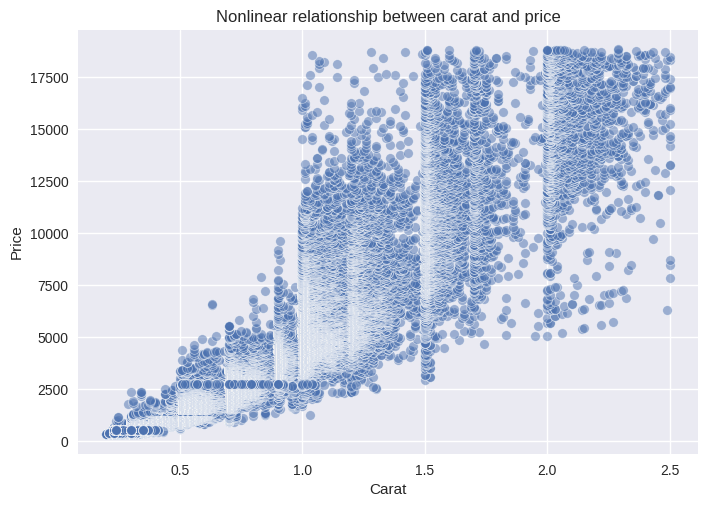

In [108]:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='carat', y='price', alpha=0.5, ax=ax)
ax.set_xlabel("Carat")
ax.set_ylabel("Price")
ax.set_title("Nonlinear relationship between carat and price")
plt.show()

In [109]:
df['log_price'] = np.log(df.price)
df['log_price']

,log_price
0,5.786897
1,5.786897
2,5.789960
3,5.811141
4,5.814131
...,...
53809,7.921898
53810,7.921898
53811,7.921898
53812,7.921898


In [110]:
df['log_carat'] = np.log(df.carat)

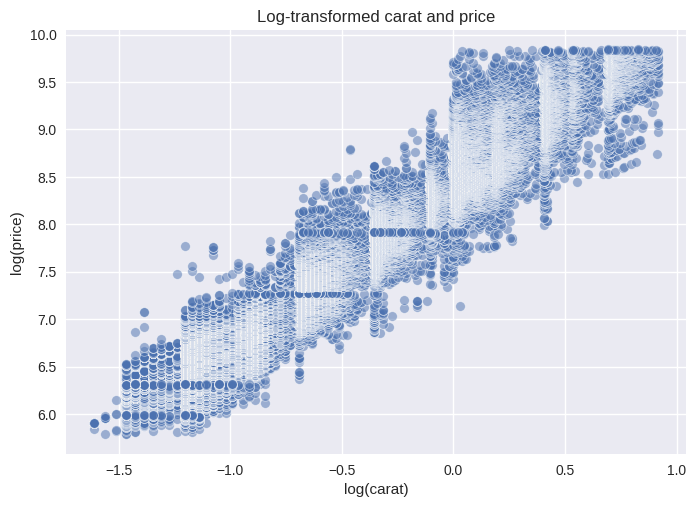

In [111]:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='log_carat', y='log_price', alpha=0.5, ax=ax)
ax.set_xlabel("log(carat)")
ax.set_ylabel("log(price)")
ax.set_title("Log-transformed carat and price")
plt.show()

In [112]:
df_X_log = df[['log_carat']]
df_X_log

,log_carat
0,-1.469676
1,-1.560648
2,-1.469676
3,-1.237874
4,-1.171183
...,...
53809,-0.328504
53810,-0.328504
53811,-0.356675
53812,-0.150823


In [113]:
df_y_log = df['log_price']
df_y_log

,log_price
0,5.786897
1,5.786897
2,5.789960
3,5.811141
4,5.814131
...,...
53809,7.921898
53810,7.921898
53811,7.921898
53812,7.921898


In [114]:
lm_log = LinearRegression()
lm_log.fit(df_X_log, df_y_log)

LinearRegression()

In [115]:
# Print the intercept and coefficients
print(lm_log.intercept_, lm_log.coef_)

8.45214175869571 [1.68137106]


**How to interpret the coefficients?**

In [116]:
# R^2
lm_log.score(df_X_log, df_y_log)

0.9334026253208663

In [117]:
# Make predictions using the new model
# using log_carat to predict log_price
log_y_pred = lm_log.predict(df_X_log)
# You must convert log price back to price
y_pred = np.exp(log_y_pred)

In [118]:
# RMSE
root_mean_squared_error(df_y, y_pred)

1513.8853713352714

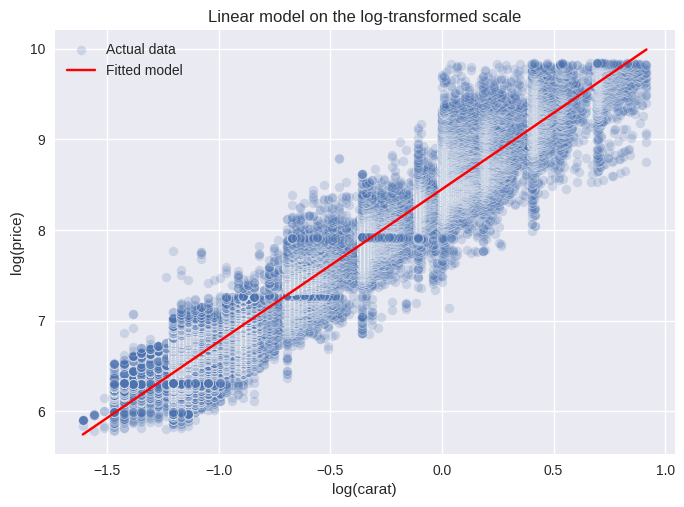

In [119]:
log_carat_grid = np.linspace(df['log_carat'].min(), df['log_carat'].max(), 200).reshape(-1, 1)
log_price_grid_pred = lm_log.predict(pd.DataFrame(log_carat_grid, columns=['log_carat']))

fig, ax = plt.subplots()
sns.scatterplot(data=df, x='log_carat', y='log_price', alpha=0.2, label="Actual data", ax=ax)
ax.plot(log_carat_grid, log_price_grid_pred, color="red", label="Fitted model")
ax.set_xlabel("log(carat)")
ax.set_ylabel("log(price)")
ax.set_title("Linear model on the log-transformed scale")
ax.legend()
plt.show()

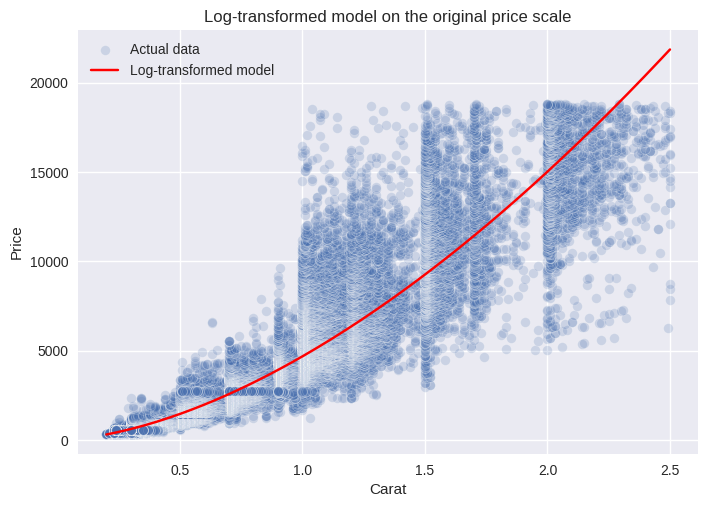

In [120]:
carat_grid = np.linspace(df['carat'].min(), df['carat'].max(), 200).reshape(-1, 1)
log_carat_grid = np.log(carat_grid)
price_grid_pred = np.exp(lm_log.predict(pd.DataFrame(log_carat_grid, columns=['log_carat'])))

fig, ax = plt.subplots()
sns.scatterplot(data=df, x='carat', y='price', alpha=0.2, label="Actual data", ax=ax)
ax.plot(carat_grid, price_grid_pred, color="red", label="Log-transformed model")
ax.set_xlabel("Carat")
ax.set_ylabel("Price")
ax.set_title("Log-transformed model on the original price scale")
ax.legend()
plt.show()

# Assignment

Build another regression model (e.g., including other variables such as color and clarity, adding categorical variable(s) to the log-transformed model). Test its performance.

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

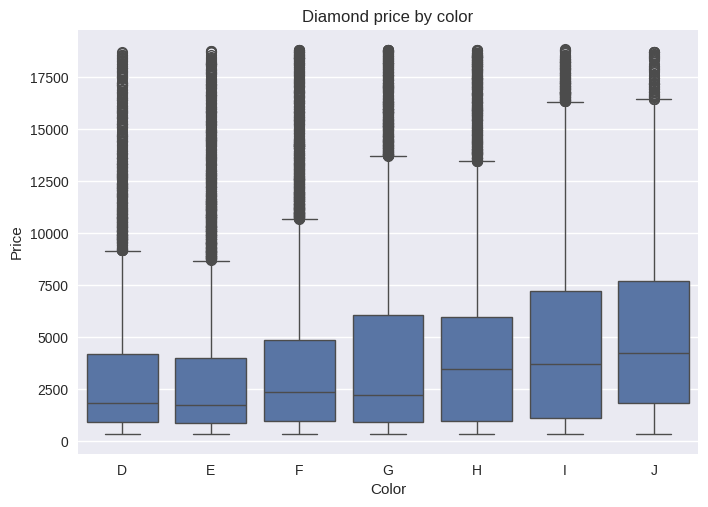

In [131]:
# Plot diamond color and diamond price in a box plot
fig, ax = plt.subplots()
sns.boxplot(data=diamonds, x='color', y='price', ax=ax)
ax.set_xlabel("Color")
ax.set_ylabel("Price")
ax.set_title("Diamond price by color")
plt

In [122]:
diamond_y = diamonds['price']
diamond_X = diamonds[['carat','color']]

In [123]:
# Use onehot encoder to encode the color category
diamond_X_onehot = pd.get_dummies(diamond_X)
diamond_X_onehot.head()

,carat,color_D,color_E,color_F,color_G,color_H,color_I,color_J
0,0.23,False,True,False,False,False,False,False
1,0.21,False,True,False,False,False,False,False
2,0.23,False,True,False,False,False,False,False
3,0.29,False,False,False,False,False,True,False
4,0.31,False,False,False,False,False,False,True


In [124]:
# Build a regression model with diamond_y and diamond_X
lr_color = LinearRegression()
lr_color.fit(diamond_X_onehot, diamond_y)

LinearRegression()

In [125]:
# Print the intercept and coefficients
print(lr_color.intercept_, lr_color.coef_)

-2702.232612338574 [ 8066.62301911   566.0037589    472.22247118   485.74090101
   480.4674773   -166.23806673  -489.72809781 -1348.46844386]


In [127]:
# Print R-Squared
lr_color.score(diamond_X_onehot, diamond_y)

0.8639619736812527

In [128]:
# Print RMSE
diamond_y_pred = lr_color.predict(diamond_X_onehot)
root_mean_squared_error(diamond_y, diamond_y_pred)

1471.4247092148123

In [ ]:
# R-Squared is very close to the R-Squared of the models using cut type.